# Springboard Apps project - Tier 3 - Complete

Welcome to the Apps project! To give you a taste of your future career, we're going to walk through exactly the kind of notebook that you'd write as a data scientist. In the process, we'll be sure to signpost the general framework for our investigation - the Data Science Pipeline - as well as give reasons for why we're doing what we're doing. We're also going to apply some of the skills and knowledge you've built up in the previous unit when reading Professor Spiegelhalter's *The Art of Statistics* (hereinafter *AoS*). 

So let's get cracking!

**Brief**

Did Apple Store apps receive better reviews than Google Play apps?

## Stages of the project

1. Sourcing and loading 
    * Load the two datasets
    * Pick the columns that we are going to work with 
    * Subsetting the data on this basis 
 
 
2. Cleaning, transforming and visualizing
    * Check the data types and fix them
    * Add a `platform` column to both the `Apple` and the `Google` dataframes
    * Changing the column names to prepare for a join 
    * Join the two data sets
    * Eliminate the `NaN` values
    * Filter only those apps that have been reviewed at least once
    * Summarize the data visually and analytically (by the column `platform`)  
  
  
3. Modelling 
    * Hypothesis formulation
    * Getting the distribution of the data
    * Permutation test 


4. Evaluating and concluding 
    * What is our conclusion?
    * What is our decision?
    * Other models we could have used. 
    

## Importing the libraries

In this case we are going to import pandas, numpy, scipy, random and matplotlib.pyplot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Fixed seed makes the random samples and permutation test reproducible.
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## Stage 1 -  Sourcing and loading data

### 1a. Source and load the data
Let's download the data from Kaggle. Kaggle is a fantastic resource: a kind of social medium for data scientists, it boasts projects, datasets and news on the freshest libraries and technologies all in one place. The data from the Apple Store can be found [here](https://www.kaggle.com/ramamet4/app-store-apple-data-set-10k-apps) and the data from Google Store can be found [here](https://www.kaggle.com/lava18/google-play-store-apps).
Download the datasets and save them in your working directory.

In [2]:
google = 'googleplaystore.csv'
Google = pd.read_csv(google)
Google.head(3)


                                                 App  ...   Android Ver
0     Photo Editor & Candy Camera & Grid & ScrapBook  ...  4.0.3 and up
1                                Coloring book moana  ...  4.0.3 and up
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ...  4.0.3 and up

[3 rows x 13 columns]

In [3]:
apple = 'AppleStore.csv'
Apple = pd.read_csv(apple)
Apple.head(3)


   Unnamed: 0         id  ... lang.num  vpp_lic
0           1  281656475  ...       10        1
1           2  281796108  ...       23        1
2           3  281940292  ...        3        1

[3 rows x 17 columns]

### 1b. Pick the columns we'll work with

From the documentation of these datasets, we can infer that the most appropriate columns to answer the brief are:

1. Google:
    * `Category` # Do we need this?
    * `Rating`
    * `Reviews`
    * `Price` (maybe)
2. Apple:    
    * `prime_genre` # Do we need this?
    * `user_rating` 
    * `rating_count_tot`
    * `price` (maybe)

### 1c. Subsetting accordingly

Let's select only those columns that we want to work with from both datasets. We'll overwrite the subsets in the original variables.

In [4]:
Google = Google[['Category', 'Rating', 'Reviews', 'Price']].copy()
Google.head(3)


         Category  Rating Reviews Price
0  ART_AND_DESIGN     4.1     159     0
1  ART_AND_DESIGN     3.9     967     0
2  ART_AND_DESIGN     4.7   87510     0

In [5]:
Apple = Apple[['prime_genre', 'user_rating', 'rating_count_tot', 'price']].copy()
Apple.head(3)


    prime_genre  user_rating  rating_count_tot  price
0         Games          4.0             21292   3.99
1  Productivity          4.0            161065   0.00
2       Weather          3.5            188583   0.00

## Stage 2 -  Cleaning, transforming and visualizing

### 2a. Check the data types for both Apple and Google, and fix them

Types are crucial for data science in Python. Let's determine whether the variables we selected in the previous section belong to the types they should do, or whether there are any errors here. 

In [6]:
Apple.dtypes


prime_genre          object
user_rating         float64
rating_count_tot      int64
price               float64
dtype: object

This is looking healthy. But what about our Google data frame?

In [7]:
Google.dtypes


Category     object
Rating      float64
Reviews      object
Price        object
dtype: object

Weird. The data type for the column 'Price' is 'object', not a numeric data type like a float or an integer. Let's investigate the unique values of this column. 

In [8]:
Google['Price'].unique()


array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

Aha! Fascinating. There are actually two issues here. 

- Firstly, there's a price called `Everyone`. That is a massive mistake! 
- Secondly, there are dollar symbols everywhere! 


Let's address the first issue first. Let's check the datapoints that have the price value `Everyone`

In [9]:
Google.loc[Google['Price'] == 'Everyone']


      Category  Rating Reviews     Price
10472      1.9    19.0    3.0M  Everyone

Thankfully, it's just one row. We've gotta get rid of it. 

In [10]:
Google = Google.loc[Google['Price'] != 'Everyone'].copy()
Google['Price'].unique()


array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

Our second problem remains: I'm seeing dollar symbols when I close my eyes! (And not in a good way). 

This is a problem because Python actually considers these values strings. So we can't do mathematical and statistical operations on them until we've made them into numbers. 

In [11]:
nosymb = Google['Price'].str.replace('$', '', regex=False)
Google['Price'] = pd.to_numeric(nosymb)
Google['Price'].head()


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

Now let's check the data types for our Google dataframe again, to verify that the 'Price' column really is numeric now.

In [12]:
Google.dtypes


Category     object
Rating      float64
Reviews      object
Price       float64
dtype: object

Notice that the column `Reviews` is still an object column. We actually need this column to be a numeric column, too. 

In [13]:
Google['Reviews'] = pd.to_numeric(Google['Reviews'])


In [14]:
Google.dtypes


Category     object
Rating      float64
Reviews       int64
Price       float64
dtype: object

### 2b. Add a `platform` column to both the `Apple` and the `Google` dataframes
Let's add a new column to both dataframe objects called `platform`: all of its values in the Google dataframe will be just 'google', and all of its values for the Apple dataframe will be just 'apple'. 

The reason we're making this column is so that we can ultimately join our Apple and Google data together, and actually test out some hypotheses to solve the problem in our brief. 

In [15]:
Apple['platform'] = 'apple'
Google['platform'] = 'google'


### 2c. Changing the column names to prepare for our join of the two datasets 
Since the easiest way to join two datasets is if they have both:
- the same number of columns
- the same column names
we need to rename the columns of `Apple` so that they're the same as the ones of `Google`, or vice versa.

In this case, we're going to change the `Apple` columns names to the names of the `Google` columns. 

This is an important step to unify the two datasets!

In [16]:
old_names = Apple.columns
new_names = Google.columns
Apple = Apple.rename(columns=dict(zip(old_names, new_names)))
Apple.head(3)


       Category  Rating  Reviews  Price platform
0         Games     4.0    21292   3.99    apple
1  Productivity     4.0   161065   0.00    apple
2       Weather     3.5   188583   0.00    apple

### 2d. Join the two datasets 
Let's combine the two datasets into a single data frame called `df`.

In [17]:
# DataFrame.append was removed in pandas 2.0; concat is its supported replacement.
df = pd.concat([Google, Apple], ignore_index=True)
df.sample(12, random_state=RANDOM_SEED)


            Category  Rating  Reviews  Price platform
8377           TOOLS     2.8       27   0.00   google
5689            GAME     4.0    29462   0.00   google
15890      Education     4.5      186   2.99    apple
16892          Games     4.0     1495   0.00    apple
2095          FAMILY     4.5   530904   0.00   google
9520          FAMILY     4.1   182363   0.00   google
17245  Entertainment     0.0        0   0.00    apple
16283          Games     4.0      205   0.00    apple
9931          SPORTS     NaN        2   0.00   google
7215          FAMILY     4.3      363   2.99   google
6201          FAMILY     2.4        7   3.99   google
8037          FAMILY     4.0     1419   0.00   google

### 2e. Eliminate the NaN values

As you can see there are some `NaN` values. We want to eliminate all these `NaN` values from the table.

In [18]:
print('Shape before dropping missing values:', df.shape)
df = df.dropna().copy()
print('Shape after dropping missing values: ', df.shape)


Shape before dropping missing values: (18037, 5)
Shape after dropping missing values:  (16563, 5)


### 2f. Filter the data so that we only see whose apps that have been reviewed at least once

Apps that haven't been reviewed yet can't help us solve our brief. 

So let's check to see if any apps have no reviews at all. 

In [19]:
df.loc[df['Reviews'] == 0].count()


Category    929
Rating      929
Reviews     929
Price       929
platform    929
dtype: int64

929 apps do not have reviews, we need to eliminate these points!

In [20]:
df = df.loc[df['Reviews'] != 0].copy()
df.shape


(15634, 5)

### 2g. Summarize the data visually and analytically (by the column `platform`)

What we need to solve our brief is a summary of the `Rating` column, but separated by the different platforms.

In [21]:
df.groupby('platform')['Rating'].describe()


           count      mean       std  min  25%  50%  75%  max
platform                                                     
apple     6268.0  4.049697  0.726943  1.0  4.0  4.5  4.5  5.0
google    9366.0  4.191757  0.515219  1.0  4.0  4.3  4.5  5.0

The sample means differ by about **0.142 rating points** (Google minus Apple). That is the observed effect; inference is still needed to determine whether a difference this large is plausible under the null hypothesis.


Let's also get a **visual summary** of the `Rating` column, separated by the different platforms. 

A good tool to use here is the boxplot!

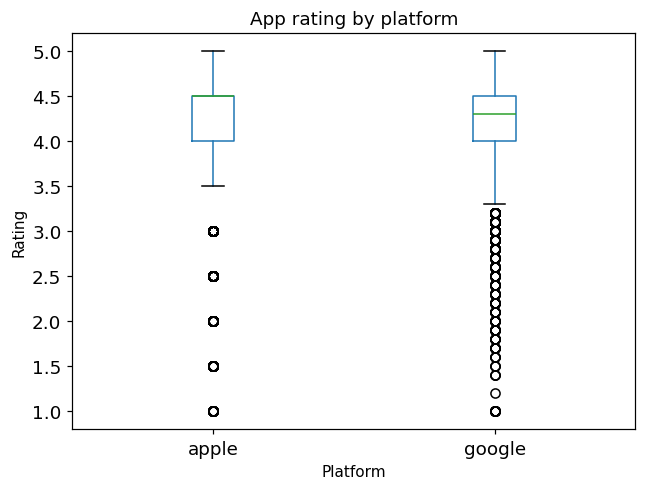

In [22]:
ax = df.boxplot(by='platform', column=['Rating'], grid=False, fontsize=12)
ax.set_title('App rating by platform')
ax.set_xlabel('Platform')
ax.set_ylabel('Rating')
plt.suptitle('')
plt.show()


Here we see the same information as in the analytical summary, but with a boxplot. Can you see how the boxplot is working here? If you need to revise your boxplots, check out this this [link](https://www.kaggle.com/ramamet4/app-store-apple-data-set-10k-apps). 

## Stage 3 - Modelling

### 3a. Hypothesis formulation

Our **Null hypothesis** is just:

**H<sub>null</sub>**: the observed difference in the mean rating of Apple Store and Google Play apps is due to chance (and thus not due to the platform).

The more interesting hypothesis is called the **Alternate hypothesis**:

**H<sub>alternative</sub>**: the observed difference in the average ratings of apple and google users is not due to chance (and is actually due to platform)

We're also going to pick a **significance level** of 0.05. 

### 3b. Getting the distribution of the data
Now that the hypotheses and significance level are defined, we can select a statistical test to determine which hypothesis to accept. 

There are many different statistical tests, all with different assumptions. You'll generate an excellent judgement about when to use which statistical tests over the Data Science Career Track course. But in general, one of the most important things to determine is the **distribution of the data**.   

In [23]:
apple = df.loc[df['platform'] == 'apple', 'Rating']
google = df.loc[df['platform'] == 'google', 'Rating']
print(f'Apple n={len(apple):,}; Google n={len(google):,}')


Apple n=6,268; Google n=9,366


In [24]:
apple_normal = stats.normaltest(apple)
print(apple_normal)


NormaltestResult(statistic=np.float64(1778.9974234584017), pvalue=np.float64(0.0))


In [25]:
google_normal = stats.normaltest(google)
print(google_normal)


NormaltestResult(statistic=np.float64(3678.6157187516856), pvalue=np.float64(0.0))


For `scipy.stats.normaltest`, the null hypothesis is normality. Both very small p-values therefore reject normality. The rating scale is discrete and bounded from 0 to 5, which also makes exact normality implausible. With these large samples, the test can detect small deviations, so the histograms below provide useful context.


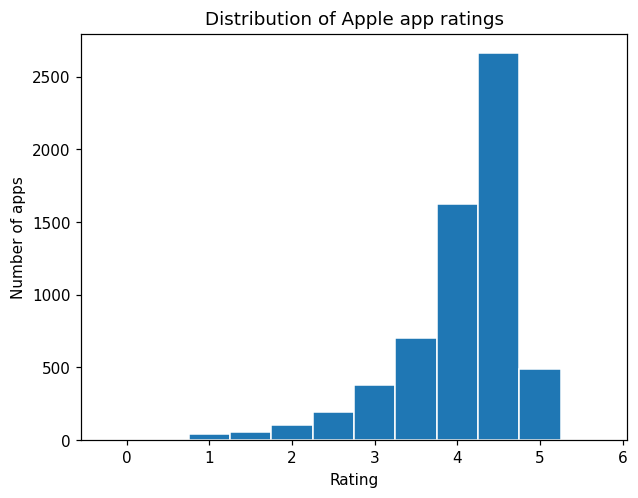

In [26]:
plt.hist(apple, bins=np.arange(-0.25, 5.76, 0.5), edgecolor='white')
plt.title('Distribution of Apple app ratings')
plt.xlabel('Rating')
plt.ylabel('Number of apps')
plt.show()


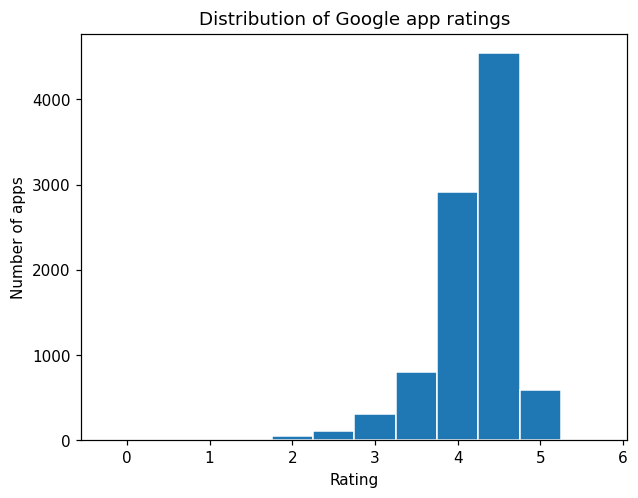

In [27]:
plt.hist(google, bins=np.arange(-0.25, 5.76, 0.5), edgecolor='white')
plt.title('Distribution of Google app ratings')
plt.xlabel('Rating')
plt.ylabel('Number of apps')
plt.show()


### 3c. Permutation test
Since the data aren't normally distributed, we're using a *non-parametric* test here. This is simply a label for statistical tests used when the data aren't normally distributed. These tests are extraordinarily powerful due to how few assumptions we need to make.  

Check out more about permutations [here.](http://rasbt.github.io/mlxtend/user_guide/evaluate/permutation_test/)

In [28]:
df['Permutation1'] = rng.permutation(df['Rating'].to_numpy())
df.groupby('platform')['Permutation1'].describe()


           count      mean       std  min  25%  50%  75%  max
platform                                                     
apple     6268.0  4.127951  0.619329  1.0  4.0  4.3  4.5  5.0
google    9366.0  4.139387  0.608639  1.0  4.0  4.3  4.5  5.0

In [29]:
df.groupby('platform')['Rating'].describe()


           count      mean       std  min  25%  50%  75%  max
platform                                                     
apple     6268.0  4.049697  0.726943  1.0  4.0  4.5  4.5  5.0
google    9366.0  4.191757  0.515219  1.0  4.0  4.3  4.5  5.0

In [30]:
# Under H0, ratings are exchangeable across platform labels.
# Store Google-minus-Apple mean differences for 10,000 shuffled assignments.
n_permutations = 10_000
n_google = len(google)
ratings = df['Rating'].to_numpy()
difference = np.empty(n_permutations)

for i in range(n_permutations):
    shuffled = rng.permutation(ratings)
    difference[i] = shuffled[:n_google].mean() - shuffled[n_google:].mean()

pd.Series(difference, name='permuted_difference').describe()


count    10000.000000
mean         0.000152
std          0.010041
min         -0.035355
25%         -0.006567
50%          0.000117
75%          0.006908
max          0.038120
Name: permuted_difference, dtype: float64

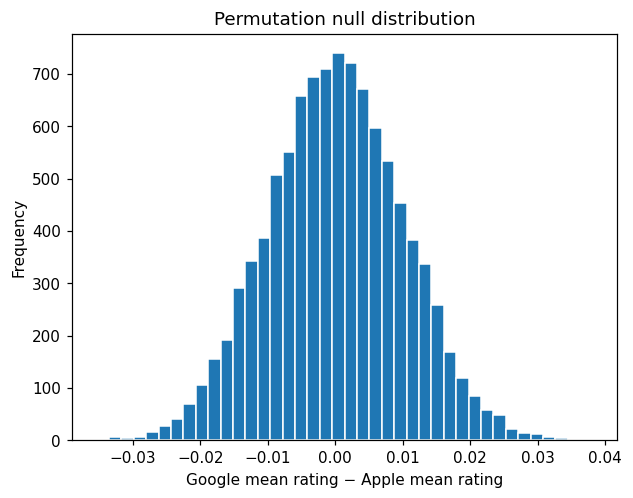

In [31]:
plt.hist(difference, bins=40, edgecolor='white')
plt.title('Permutation null distribution')
plt.xlabel('Google mean rating − Apple mean rating')
plt.ylabel('Frequency')
plt.show()


In [32]:
obs_difference = google.mean() - apple.mean()
abs_obs_difference = abs(obs_difference)
print(f'Observed difference (Google − Apple): {obs_difference:.6f}')
print(f'Absolute observed difference: {abs_obs_difference:.6f}')


Observed difference (Google − Apple): 0.142061
Absolute observed difference: 0.142061


## Stage 4 -  Evaluating and concluding
### 4a. What is our conclusion?

In [33]:
# Two-sided Monte Carlo p-value. The +1 correction avoids reporting an
# impossible exact zero when no simulated statistic is as extreme as observed.
extreme_count = np.count_nonzero(np.abs(difference) >= abs_obs_difference)
p_value = (extreme_count + 1) / (n_permutations + 1)

# Standardized effect size (Cohen's d) helps assess practical magnitude.
n_a, n_g = len(apple), len(google)
pooled_sd = np.sqrt(((n_a - 1) * apple.var(ddof=1) +
                     (n_g - 1) * google.var(ddof=1)) / (n_a + n_g - 2))
cohens_d = obs_difference / pooled_sd

print(f'Extreme permutations: {extreme_count} of {n_permutations}')
print(f'Two-sided Monte Carlo p-value: {p_value:.6f}')
print(f"Cohen's d: {cohens_d:.3f}")
print('Decision at alpha=0.05:', 'Reject H0' if p_value <= 0.05 else 'Fail to reject H0')


Extreme permutations: 0 of 10000
Two-sided Monte Carlo p-value: 0.000100
Cohen's d: 0.233
Decision at alpha=0.05: Reject H0


### 4b. What is our decision?
The two-sided permutation p-value is below 0.05, so we reject the null hypothesis of equal platform-level mean ratings. Google apps have the higher sample mean (about 4.19 versus 4.05), a difference of roughly 0.142 points. The standardized effect is small, however, so statistical significance should not be confused with a large practical advantage. Using rating alone as specified in the brief, the evidence favors **Google Play**.


### 4c. Limitations and next steps
This is an observational comparison of app listings, not a randomized experiment, so it does not establish that the platform itself causes the rating difference. The stores may differ in app mix, review behavior, duplicate listings, and rating-count distribution. A stronger follow-up would compare matched categories, consider weighting or stratifying by review count, remove duplicate apps where appropriate, report confidence intervals, and examine robustness with tests such as Mann–Whitney U or Welch's t-test. Product fit, security, catalog size, and integration cost should also inform the final platform choice.
